# Onde nella corda tesa
Giovanni Nicola D'Aloisio, n. di matricola 494722; prova svolta il 4 maggio 2021.

---

## Introduzione
<p align="justify">Quando si agita con moto armonico una corda vincolata, l'onda armonica che ne risulta si propaga e raggiunge l'estremità a cui è vincolata la corda, riflettendosi e tornando indietro con la medesima frequenza ed ampiezza. L'onda che rimbalza si sovrappone a quella successiva, e tale interferenza conduce alla formazione di un'onda stazionaria sulla corda, che si propaga con una certa velocità senza disperdersi, in modo proporzionale alla densità lineare del materiale con cui è fatta. Ciò non si verifica sempre, in quanto una corda rigida, ovvero con modulo di Young $E \pm \delta E$ molto alto, presenta delle dispersioni, che possono essere valutate mediante un parametro $\alpha$ sperimentale.

## Scopi della prova
Gli obiettivi di questa prova sono:
* Verificare la propagazione non-dispersiva delle onde in una corda flessibile di nylon;
* Determinare la densità lineare di tale corda;
* Verificare la propagazione dispersiva delle onde in un cavo di acciaio e determinarne il parametro di dispersione e il modulo di Young.

## Apparato sperimentale
Per raggiungere gli obiettivi della prova si dispone di:
* Due corde, una in nylon e l'altra in acciaio;
* Un metro a nastro, per misurare la lunghezza della corda;
* Una serie di masse, di cui una modellata in modo da reggerne altre;
* Un oscillatore meccanico, che imprime un'oscillazione alla corda tesa, eventualmente alimentato da un generatore di frequenze;
* Un supporto, per fissare l'altro estremo della corda;
* Una puleggia, che sostiene $\tau = mg$, con $m$ massa agganciata.

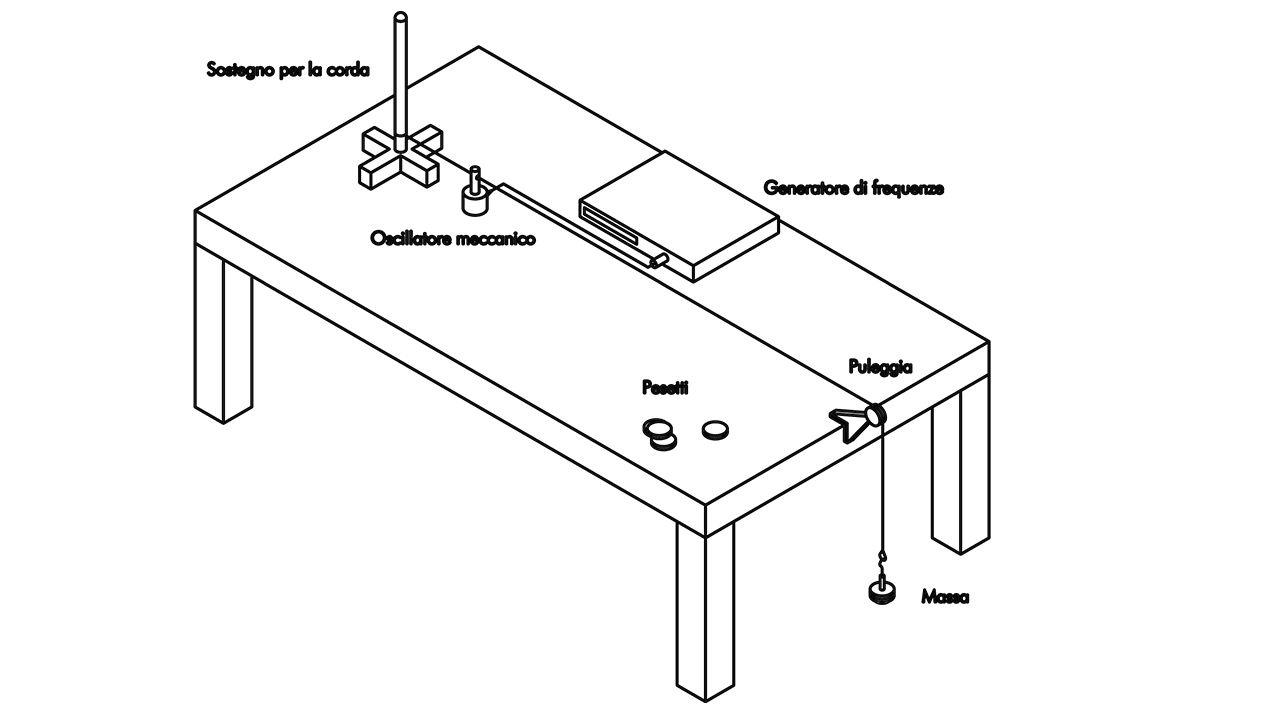

## Procedura
<p align="justify">In un oscillatore reale immerso in un fluido come l'aria sono sempre presenti forze di attrito, per cui per mantenerlo in oscillazione occorre fornire una certa quantità di energia, attraverso una forza periodica esterna. Si dimostra che in un intervallo di tempo sufficientemente elevato, il regime transitorio si estingue, domina la soluzione stazionaria, e le sue caratteristiche dipendono unicamente dalla forza esterna $F_0$.

<p align="justify">L'ampiezza dipende dall'intensità della forza esterna e dalla sua frequenza. La sua frequenza naturale $\omega_0$ è la sua frequenza quando non sono presenti forze esterne, ma se quella forzante $\omega_f$ fosse sufficientemente vicina a essa, il sistema oscillerebbe con ampiezza relativamente più alta. Questo fenomeno prende il nome di risonanza e tale frequenza è detta frequenza di risonanza.

<p align="justify">Nella prima parte della prova, si ricercano le frequenze di risonanza della corda soggetta a una tensione $\tau = mg$, dovuta a una massa di dimensione nota a essa collegata, e le si plottano su un diagramma $\omega_n - k_n$; dal best fit della legge:

> $\omega_n = k_n c$

<p align="justify">Si risale alla velocità di propagazione delle onde nella corda di nylon a quella data tensione. Si ricordi che $\omega_n=2 \pi f_n$ è la pulsazione dell'onda e che $k_n = {n \pi \over L}$ è il vettore d'onda associato all'armonica, con $L \pm \delta L$ lunghezza della corda dall'oscillatore alla puleggia.

<p align="justify">Nella seconda parte della prova, per una serie di tensioni si determinano le velocità di propagazione delle onde e, scelta un'armonica, si costruisce un diagramma $\tau$ - $c^2$, che fittato secondo la legge:

> $\tau = c^2 \mu$

<p align="justify">permette di calcolare la densità lineare della corda $\mu \pm \delta \mu$, che può anche essere calcolata con la semplice definizione "statica":

> $\mu = {m \over L} \quad $ (con $m \pm \delta m$ = massa e $L \pm \delta L$ = lunghezza complessiva della corda)

<p align="justify">Nell'ultima parte della prova si verifica la relazione di dispersione nel cavo di acciaio:

> $\omega_n = k_n c \sqrt{1+\alpha k_n^2}$

<p align="justify">e si determina il valore del parametro non-lineare $\alpha \pm \delta \alpha$, nonché il modulo di Young dell'acciaio, pari a:

> $E={4 \alpha \tau \over\pi a^4}$

<p align="justify">raccogliendo i dati sperimentali necessari e fittando le leggi come già visto nella prima parte della prova. Si ricordi che il modulo di Young, detto anche modulo elastico per la trazione/compressione, esprime il rapporto tra tensione e deformazione di un materiale in condizioni di carico monoassiale e comportamento elastico.

<p align="justify">Nelle leggi esposte, $a$ è il raggio del cavo di acciaio a sezione circolare, mentre $\tau$ e $\alpha$ sono rispettivamente la tensione e il parametro non-lineare del cavo calcolati in precedenza.

## Analisi dei dati sperimentali
In questa sezione sono riportati i dati sperimentali e gli script in Python utilizzati per la loro analisi statistica, con i relativi risultati (valori numerici e grafici).

In [1]:
import numpy as np  
from matplotlib import pyplot as plt 
from scipy.optimize import curve_fit 
from scipy import odr
from scipy import constants
from ipywidgets import interact, interact_manual, FloatSlider, Checkbox, BoundedFloatText
from google.colab import files
import json

### Velocità di propagazione non-dispersiva delle onde in una corda flessibile di nylon

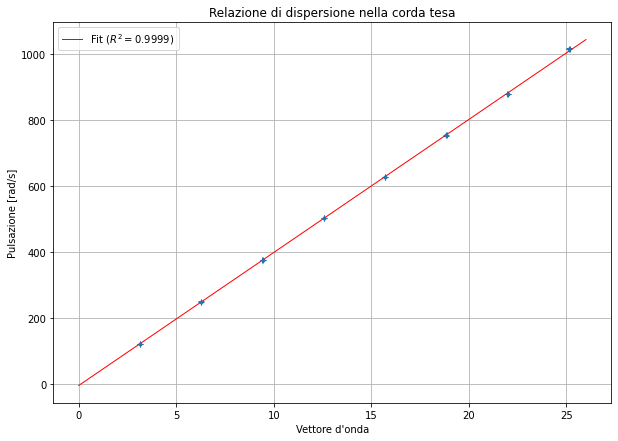

y₀ =    -4.9107 +/- 1.2840
c =    40.3848 +/- 0.1174
R² = 0.9998799957624578


In [2]:
# Importazione dei dati per il fit (S.I.)
 
massa = 0.300                 # Massa attaccata
tao = massa*constants.g       # Tensione del filo
L = 1.000                     # Lunghezza del filo dall'oscillatore alla puleggia
L_err = 0.001                 # Errore sulla lunghezza del filo
L_percent_err = L_err/L       # Errore relativo sulla lunghezza del filo
f_err = 0.05                  # Errore relativo sulla frequenza d'onda
 
# L'errore relativo su kappa è pari all'errore relativo su L, quindi l'errore assoluto cresce con k
 
# dati è una lista di liste [n, f_n] dove n = numero dell'armonica e f_n = frequenza in Hz
dati_raw = [[1, 19.40], [2, 39.75], [3, 59.70], [4, 80.00], [5, 100.00], [6, 120.00], [7, 140.00], [8, 162.00]]
 
dati = []
 
for raw in dati_raw:
  #raw = [n, f_n]
  #final = [k, omega_k]
  final = [np.pi*raw[0]/L, 2*np.pi*raw[1]]
  final.append(np.pi*raw[0]*L_err/(L**2))            # Calcolo l'errore assoluto per ogni k e lo appendo a final
  final.append(2*np.pi*f_err)                        # Calcolo l'errore assoluto per ogni omega e lo appendo a final
  dati.append(final)
 
dati = np.array(dati)
 
kappa = dati[:,0]
omega = dati[:,1]
kappa_err = dati[:,2]
omega_err = dati[:,3]
 
# Definizione della funzione di fit
 
def retta(p,c): 
  return p[0]+p[1]*c
 
# Fitting routine, per definire la funzione che stampa il grafico e eseguire il fit dei dati
 
def fitplot_retta(y0, c, print_output=True, plot_guess=False):
 
  retta_model = odr.Model(retta)
  fit_data = odr.RealData(kappa, omega, sx=kappa_err, sy=omega_err)
  beta0 = np.array([y0,c])                           # Array dei guess iniziali
  
  fit = odr.ODR(fit_data, retta_model, beta0=beta0)
  global out
  out = fit.run()
  
  # Calcolo di R_squared
  residuals = omega - retta(out.beta, kappa)
  ss_res = np.sum(residuals**2)
  ss_tot = np.sum((omega-np.mean(omega))**2)
  r_squared = 1 - (ss_res / ss_tot)
  
  # Plot dei risultati del fit
 
  sample_x = np.linspace(0,np.amax(c),1000)
  plt.show()
  plt.figure(figsize=(10,7))
 
  if plot_guess:
    plt.plot(sample_x, retta(beta0,sample_x),'--', color=[0.3,0.7,0], label="Guess", linewidth=2) # plot guess
  
  plt.errorbar(kappa, omega, xerr=kappa_err, yerr=omega_err, linestyle='None', capsize=3, marker='.')
  plt.title("Relazione di dispersione nella corda tesa")
  plt.xlabel("Vettore d'onda")
  plt.ylabel("Pulsazione [rad/s]")
  plt.plot(sample_x, retta(out.beta, sample_x), color=[1,0,0], label="Fit ($R^2=${:.4f})".format(r_squared), linewidth=1)
  plt.grid(which='both')
  plt.legend()
  plt.show()
 
  if print_output:
    print("y₀ = {:10.4f} +/- {:2.4f}".format(out.beta[0],out.sd_beta[0]))
    print("c = {:10.4f} +/- {:2.4f}".format(out.beta[1],out.sd_beta[1]))
    print("R² = "+str(r_squared))
 
fitplot_retta(3, 26)

### Densità lineare di una corda flessibile di nylon

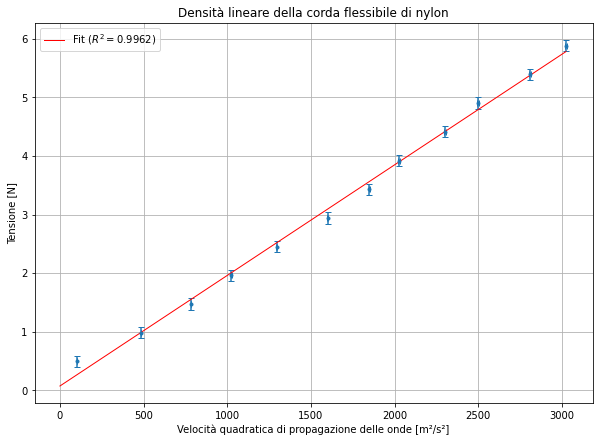

y₀ = 0.070445098614785 +/- 0.068793734265832
μ = 0.0018888485 +/- 0.0000367482
R² = 0.9962405611435156
μₛ = 0.0019746835 +/- 0.0000516328


In [4]:
# Importazione dei dati per il fit (S.I.)
 
m_corda = 0.0039            # Peso del filo
m_corda_err = 0.0001        # Errore sul peso del filo
L_corda = 1.975             # Lunghezza totale del filo
L = 1.000                   # Lunghezza del filo da oscillatore a vincolo
L_err = 0.001               # Errore sulla lunghezza del filo
L_percent_err = L_err/L     # Errore relativo sulla lunghezza del filo da oscillatore a vincolo
f_err = 0.01                # Errore relativo sulla frequenza d'onda
n = 2                       # Armonica di riferimento
k = (n*np.pi)/L             # Vettore d'onda
m_err = 0.001               # Errore su ogni pesetto
 
# L'errore relativo su kappa è pari all'errore relativo su L, quindi l'errore assoluto cresce con k
 
# dati è una lista di liste [m, f_n] dove m = massa e f_n = frequenza in Hz della 2^ armonica
 
dati_raw = [[0.050, 10.00],[0.100, 22.00],[0.150, 28.00],[0.200, 32.00],[0.250, 36.00],[0.300, 40.00],[0.350, 43.00],[0.400, 45.00],[0.450, 48.00],[0.500, 50.00],[0.550, 53.00],[0.600, 55.00]]
 
dati = []
 
for raw in dati_raw:
  #raw = [m, f_n]
  #final = [cquadro, tau]
  final = [(2*(np.pi)*raw[1]/k)**2, (constants.g)*(raw[0])]
  final.append(2*((f_err/raw[1])+L_percent_err)*final[0])          # Calcolo l'errore assoluto per ogni cquadro e lo appendo a final
  final.append(final[1]*constants.g*(m_err/raw[0]))                # Calcolo l'errore assoluto per ogni tau e lo appendo a final
  dati.append(final)
 
dati = np.array(dati)
 
kappa = dati[:,0]
omega = dati[:,1]
kappa_err = dati[:,2]
omega_err = dati[:,3]
 
# Definizione della funzione di fit
 
def retta(p,mu):
  return p[0]+p[1]*mu
 
# Fitting routine, per definire la funzione che stampa il grafico e eseguire il fit dei dati
 
def fitplot_retta(y0, mu, print_output=True, plot_guess=False):
 
  retta_model = odr.Model(retta)
  fit_data = odr.RealData(kappa, omega, sx=kappa_err, sy=omega_err)
 
  beta0 = np.array([y0,mu])                                # Array dei guess iniziali
  
  fit = odr.ODR(fit_data, retta_model, beta0=beta0)
 
  global out
  
  out = fit.run()
  
  # Calcolo di R_squared, per valutare la bontà del fit
  
  residuals = omega - retta(out.beta, kappa)
  ss_res = np.sum(residuals**2)
  ss_tot = np.sum((omega-np.mean(omega))**2)
  r_squared = 1 - (ss_res / ss_tot)
  
  # Plot dei risultati del fit
  
  sample_x = np.linspace(0,np.amax(kappa),1000)
  plt.figure(figsize=(10,7))
  
  if plot_guess:
    plt.plot(sample_x, retta(beta0,sample_x),'--', color=[0.3,0.7,0], label="Guess", linewidth=2) # plot guess
  
  plt.errorbar(kappa, omega, xerr=kappa_err, yerr=omega_err, linestyle='None', capsize=3, marker='.')
  plt.title("Densità lineare della corda flessibile di nylon")
  plt.xlabel("Velocità quadratica di propagazione delle onde [m²/s²]")
  plt.ylabel("Tensione [N]")
  plt.plot(sample_x, retta(out.beta, sample_x), color=[1,0,0], label="Fit ($R^2=${:.4f})".format(r_squared), linewidth=1)
  plt.grid(which='both')
  plt.legend()
  plt.show()
 
  if print_output:
    print("y₀ = {:10.15f} +/- {:2.15f}".format(out.beta[0],out.sd_beta[0]))
    print("μ = {:2.10f} +/- {:2.10f}".format(out.beta[1],out.sd_beta[1]))
    print("R² = "+str(r_squared))
 
fitplot_retta(0, 12000)
 
# Stampo la densità lineare calcolata con la definizione
 
mu_static = m_corda/L_corda
mu_static_err = ((L_err/L_corda)+(m_corda_err/m_corda))*mu_static
print("μₛ = {:2.10f} +/- {:2.10f}".format(mu_static,mu_static_err))

### Propagazione dispersiva delle onde in una corda rigida di acciaio e calcolo del modulo di Young

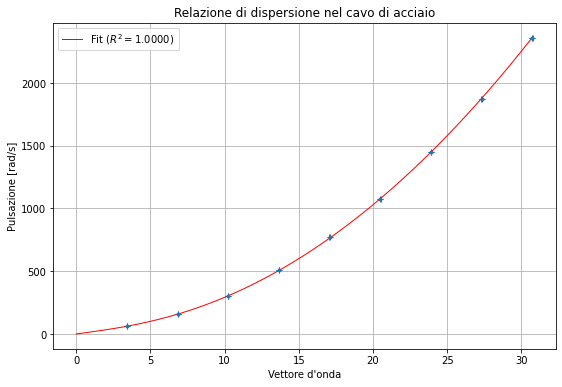

α = 0.0234 +/- 0.0008
c = 15.99 +/- 0.23
R² = 0.9999627334366802
E = 198085467615.90347 +/- 7850782164.923075


In [3]:
# Importazione dei dati per il fit (S.I.)
 
massa_pesetto = 0.6508
massa_pesetto_err = 0.00005
massa_pesetto_rel = massa_pesetto_err/massa_pesetto
t_acciaio = massa_pesetto*constants.g
t_acciaio_err = t_acciaio*massa_pesetto_rel
 
r_acciaio = 0.001980/2
r_acciaio_err = 0.000005
r_acciaio_percent = r_acciaio_err/r_acciaio
L = 0.92
L_err = 0.001
L_percent_err = L_err/L
g = constants.g
f_err = 0.05
 
# L'errore relativo su kappa è pari all'errore relativo su L, quindi l'errore assoluto cresce con k
 
# dati è una lista di liste [n, f_n] dove n = numero armonico e f_n = frequenza in Hz
 
dati_raw = [[1, 10.00], [2, 25.00], [3, 48.00], [4, 81.00], [5, 123.00], [6, 171.00], [7, 231.00], [8, 298.00], [9, 375.00]]
 
dati = [] 
for raw in dati_raw:
  #raw = [n, f_n]
  #final = [k, omega_k]
  final = [np.pi*raw[0]/L, 2*np.pi*raw[1]]
  final.append(np.pi*raw[0]*L_err/(L**2))               # Calcolo l'errore assoluto per ogni k e lo appendo a final
  final.append(2*np.pi*f_err)                        # Calcolo l'errore assoluto per ogni omega e lo appendo a final
  
  dati.append(final)
 
dati = np.array(dati)
 
kappa = dati[:,0]
omega = dati[:,1]
kappa_err = dati[:,2]
omega_err = dati[:,3]
 
# Definizione della funzione di fit
 
def omega_dispersiva(p,delta_k): 
  return delta_k*p[1]*np.sqrt(1+p[0]*delta_k**2)
 
# Fitting routine, per definire la funzione che stampa il grafico e eseguire il fit dei dati
 
def fitplot_omega_dispersiva(alpha, c, print_output=True, plot_guess=False):
 
  omega_dispersiva_model = odr.Model(omega_dispersiva)
  fit_data = odr.RealData(kappa, omega, sx=kappa_err, sy=omega_err)
  beta0 = np.array([alpha, c]) #array of initial guesses
  
  fit = odr.ODR(fit_data, omega_dispersiva_model, beta0=beta0)
  global out
  out = fit.run()
  
  # Calcolo di R_squared
  
  residuals = omega - omega_dispersiva(out.beta, kappa)
  ss_res = np.sum(residuals**2)
  ss_tot = np.sum((omega-np.mean(omega))**2)
  r_squared = 1 - (ss_res / ss_tot)
  
  # Plot dei risultati del fit
 
  sample_x = np.linspace(0,np.amax(kappa),1000)
  plt.show()
 
  plt.figure(figsize=(9, 6))
 
  if plot_guess:
    plt.plot(sample_x, omega_dispersiva(beta0,sample_x),'--', color=[0.3,0.7,0], label="Guess", linewidth=1) # plot guess
  
  plt.errorbar(kappa, omega, xerr=kappa_err, yerr=omega_err, linestyle='None', capsize=3, marker='.')
  plt.title("Relazione di dispersione nel cavo di acciaio")
  plt.xlabel("Vettore d'onda")
  plt.ylabel("Pulsazione [rad/s]")
  plt.plot(sample_x, omega_dispersiva(out.beta, sample_x), color=[1,0,0], label="Fit ($R^2=${:.4f})".format(r_squared), linewidth=1)
  plt.grid(which='both')
  plt.legend()
  plt.show()
 
  # Calcolo modulo di Young
  young = (4*out.beta[0]*massa_pesetto*g)/(np.pi*(r_acciaio**4))
  young_err = young*((out.sd_beta[0]/out.beta[0])+(t_acciaio_err/t_acciaio)+r_acciaio_percent);
  
  if print_output:
    print("α = {:5.4f} +/- {:2.4f}".format(out.beta[0],out.sd_beta[0]))
    print("c = {:5.2f} +/- {:2.2f}".format(out.beta[1],out.sd_beta[1]))
    print("R² = "+str(r_squared))
    print("E = {} +/- {}".format(young,young_err))
 
fitplot_omega_dispersiva(0, 40)

## Discussione dei risultati e conclusioni

<p align="justify">La velocità di propagazione delle onde nella corda di nylon soggetta alla tensione di $2.94 \pm 0.03 \text{ N}$ è:

> $c = (40.4 \pm 0.1) \text{ m/s}$

<p align="justify">Dato che questo valore è legato alla tensione dalla legge $c = \sqrt{\tau \over \mu}$, ci si aspetta una lenta crescita all'aumentare della massa attaccata.

<p align="justify">Inoltre, il best fit dei dati raccolti nella seconda parte della prova, a valori diversi di tensione e a parità di vettore d'onda, e la misura della massa e della lunghezza della corda hanno prodotto come densità lineare del nylon intrecciato i seguenti valori:

> $\mu_d = (1.89 \pm 0.04) \times 10^{-3} \text{ kg/m} \quad \simeq \quad \mu_s = (1.98 \pm 0.05) \times 10^{-3} \text{ kg/m}$

<p align="justify">Dato che le misure sono indipendenti e risulta $| \mu_d - \mu_s | \leq \delta\mu_d + \delta\mu_s$ esse sono ben compatibili e quindi ugualmente valide.

<p align="justify">Infine, la rigidità del cavo di acciaio ha evidenziato un fattore di dispersione $\alpha = (2.34 \pm 0.08) \times 10^{-2}$; questo valore è veritiero in quanto porta al calcolo del seguente modulo di Young:

> $E = (1.98 \pm 0.08) \times 10^{11} \text{ N/m}^2$

<p align="justify">Tenendo conto del fatto che l'acciaio è una lega del ferro-carbonio al $(0.05 \div 2.06) \% $, e che il valore medio tabulato per tale grandezza a 20°C è $2.1 \times 10^{11} \text{ N/m}^2$, si considera corretto.

<p align="justify">Per i risultati ottenuti, si considerano allora raggiunti tutti gli obiettivi della prova.